# H1N1 and Seasonal Flu Vaccines - Analysis

## 1. Imports and Setup

In [69]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve

pd.set_option("display.max_columns", 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)
sns.set_style("whitegrid")

%matplotlib inline

RANDOM_SEED = 6

## 2. Load Data

In [70]:
DATA_PATH = Path.cwd()
print(f"Data path: {DATA_PATH}")

features_df = pd.read_csv(
    DATA_PATH / "training_set_features.csv", index_col="respondent_id"
)
labels_df = pd.read_csv(
    DATA_PATH / "training_set_labels.csv", index_col="respondent_id"
)

print("✓ Datasets loaded successfully!")
print(f"Features DataFrame Shape: {features_df.shape}")
print(f"Labels DataFrame Shape: {labels_df.shape}")

Data path: c:\Users\user\Projects\predict H1N1 and Seasonal Flu Vaccines
✓ Datasets loaded successfully!
Features DataFrame Shape: (26707, 35)
Labels DataFrame Shape: (26707, 2)


In [71]:
np.testing.assert_array_equal(features_df.index.values, labels_df.index.values)
print("✓ Indices match between features and labels")

✓ Indices match between features and labels


## 3. Basic Data Inspection

In [72]:
print(f"Shape: {features_df.shape}")
print(f"Memory usage: {features_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("Memory is manageable for local analysis. Could optimize with float32 for larger datasets.")

print(features_df.dtypes)

Shape: (26707, 35)
Memory usage: 21.99 MB
Memory is manageable for local analysis. Could optimize with float32 for larger datasets.
h1n1_concern                   float64
h1n1_knowledge                 float64
behavioral_antiviral_meds      float64
behavioral_avoidance           float64
behavioral_face_mask           float64
behavioral_wash_hands          float64
behavioral_large_gatherings    float64
behavioral_outside_home        float64
behavioral_touch_face          float64
doctor_recc_h1n1               float64
doctor_recc_seasonal           float64
chronic_med_condition          float64
child_under_6_months           float64
health_worker                  float64
health_insurance               float64
opinion_h1n1_vacc_effective    float64
opinion_h1n1_risk              float64
opinion_h1n1_sick_from_vacc    float64
opinion_seas_vacc_effective    float64
opinion_seas_risk              float64
opinion_seas_sick_from_vacc    float64
age_group                       object
education 

In [73]:
print("First 5 rows of features:")
display(features_df.head())

First 5 rows of features:


,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,doctor_recc_seasonal,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation
respondent_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,1.0,2.0,2.0,1.0,2.0,55 - 64 Years,< 12 Years,White,Female,Below Poverty,Not Married,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN
1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,4.0,4.0,4.0,2.0,4.0,35 - 44 Years,12 Years,White,Male,Below Poverty,Not Married,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe
2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1.0,0.0,0.0,NaN,3.0,1.0,1.0,4.0,1.0,2.0,18 - 34 Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Not Married,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo
3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,NaN,3.0,3.0,5.0,5.0,4.0,1.0,65+ Years,12 Years,White,Female,Below Poverty,Not Married,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN
4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,3.0,3.0,2.0,3.0,1.0,4.0,45 - 54 Years,Some College,White,Female,"<= $75,000, Above Poverty",Married,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb


In [74]:
print("First 5 rows of labels:")
display(labels_df.head())

First 5 rows of labels:


,h1n1_vaccine,seasonal_vaccine
respondent_id,,
0,0,0
1,0,1
2,0,0
3,0,1
4,0,0


## 4. Missing Values Analysis

In [75]:


missing_features = features_df.isnull().sum()
missing_features_pct = (missing_features / len(features_df) * 100).round(2)

missing_summary = pd.DataFrame({
    'Missing Count': missing_features,
    'Missing Percentage': missing_features_pct
})

print("Missing values in features (sorted by percentage):")
display(missing_summary[missing_summary['Missing Count'] > 0].sort_values('Missing Percentage', ascending=False))

print("\nMissing values in labels:")
print(labels_df.isnull().sum())

# Add explanation
print("\n NOTE: High missingness in employment/income fields likely due to:")
print("   - Unemployed respondents")
print("   - Respondents who preferred not to answer")
print("   - These will be imputed with median values in the pipeline")

Missing values in features (sorted by percentage):


,Missing Count,Missing Percentage
employment_occupation,13470,50.44
employment_industry,13330,49.91
health_insurance,12274,45.96
income_poverty,4423,16.56
doctor_recc_h1n1,2160,8.09
doctor_recc_seasonal,2160,8.09
rent_or_own,2042,7.65
employment_status,1463,5.48
marital_status,1408,5.27
education,1407,5.27



Missing values in labels:
h1n1_vaccine        0
seasonal_vaccine    0
dtype: int64

 NOTE: High missingness in employment/income fields likely due to:
   - Unemployed respondents
   - Respondents who preferred not to answer
   - These will be imputed with median values in the pipeline


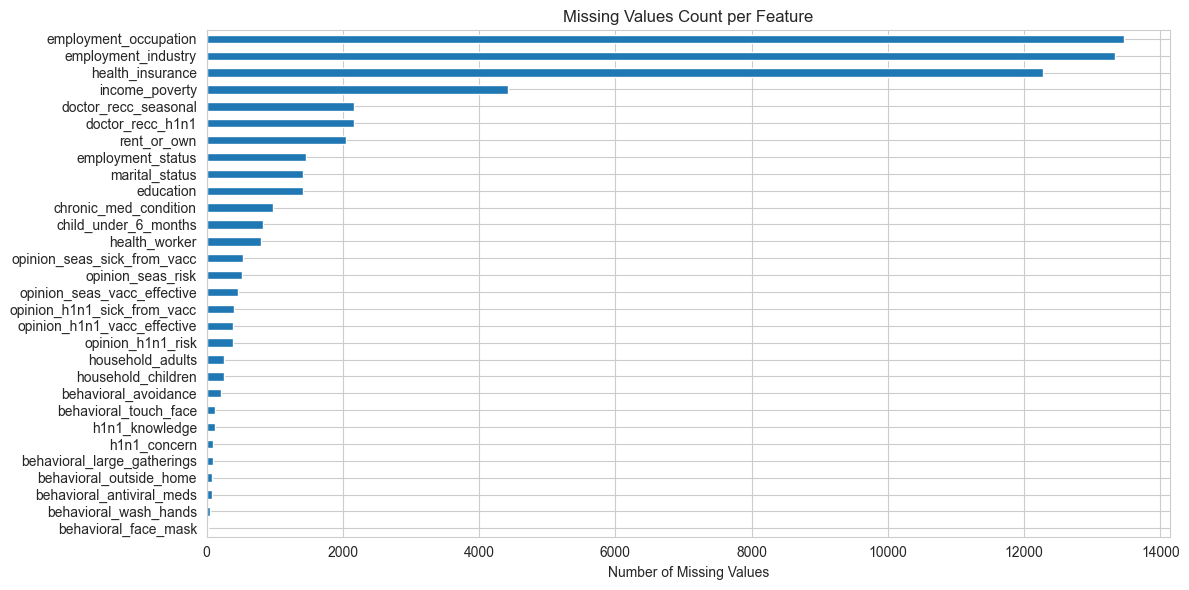

In [76]:
plt.figure(figsize=(12, 6))
missing_vals = features_df.isnull().sum()
missing_vals = missing_vals[missing_vals > 0]
missing_vals.sort_values(ascending=True).plot(kind='barh')
plt.title('Missing Values Count per Feature')
plt.xlabel('Number of Missing Values')
plt.tight_layout()
plt.show()

## 5. Target Variable Analysis

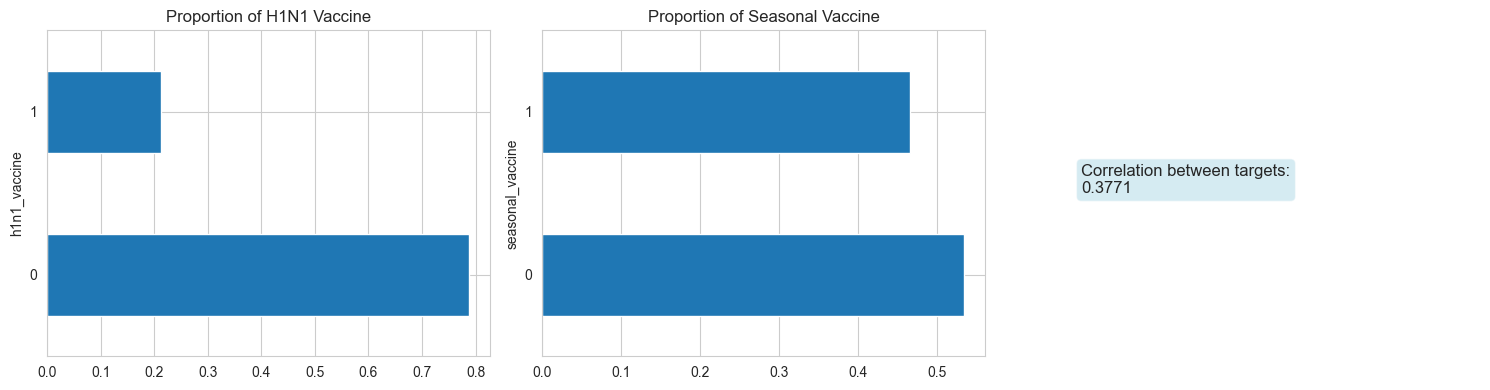

In [77]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

n_obs = labels_df.shape[0]
(labels_df["h1n1_vaccine"]
 .value_counts()
 .div(n_obs)
 .plot.barh(title="Proportion of H1N1 Vaccine", ax=axes[0]))
axes[0].set_ylabel("h1n1_vaccine")

(labels_df["seasonal_vaccine"]
 .value_counts()
 .div(n_obs)
 .plot.barh(title="Proportion of Seasonal Vaccine", ax=axes[1]))
axes[1].set_ylabel("seasonal_vaccine")

correlation = labels_df["h1n1_vaccine"].corr(labels_df["seasonal_vaccine"], method="pearson")
axes[2].text(0.1, 0.5, f"Correlation between targets:\n{correlation:.4f}", 
            fontsize=12, transform=axes[2].transAxes,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.5))
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [78]:
crosstab = pd.crosstab(
    labels_df["h1n1_vaccine"], labels_df["seasonal_vaccine"], 
    margins=True, normalize=True
)
print("Normalized crosstab of H1N1 vs Seasonal Vaccine:")
display(crosstab)

Normalized crosstab of H1N1 vs Seasonal Vaccine:


seasonal_vaccine,0,1,All
h1n1_vaccine,,,
0,0.497810,0.289737,0.787546
1,0.036582,0.175871,0.212454
All,0.534392,0.465608,1.000000


## 6. Feature Analysis

In [79]:
numerical_cols = features_df.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_cols = features_df.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical features ({len(numerical_cols)}): {numerical_cols[:10]}...")
print(f"\nCategorical features ({len(categorical_cols)}): {categorical_cols[:10]}...")

Numerical features (23): ['h1n1_concern', 'h1n1_knowledge', 'behavioral_antiviral_meds', 'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands', 'behavioral_large_gatherings', 'behavioral_outside_home', 'behavioral_touch_face', 'doctor_recc_h1n1']...

Categorical features (12): ['age_group', 'education', 'race', 'sex', 'income_poverty', 'marital_status', 'rent_or_own', 'employment_status', 'hhs_geo_region', 'census_msa']...


In [80]:
print("Summary statistics for numerical features:")
display(features_df[numerical_cols].describe().T)

Summary statistics for numerical features:


,count,mean,std,min,25%,50%,75%,max
h1n1_concern,26615.0,1.618486,0.910311,0.0,1.0,2.0,2.0,3.0
h1n1_knowledge,26591.0,1.262532,0.618149,0.0,1.0,1.0,2.0,2.0
behavioral_antiviral_meds,26636.0,0.048844,0.215545,0.0,0.0,0.0,0.0,1.0
behavioral_avoidance,26499.0,0.725612,0.446214,0.0,0.0,1.0,1.0,1.0
behavioral_face_mask,26688.0,0.068982,0.253429,0.0,0.0,0.0,0.0,1.0
behavioral_wash_hands,26665.0,0.825614,0.379448,0.0,1.0,1.0,1.0,1.0
behavioral_large_gatherings,26620.0,0.358640,0.479610,0.0,0.0,0.0,1.0,1.0
behavioral_outside_home,26625.0,0.337315,0.472802,0.0,0.0,0.0,1.0,1.0
behavioral_touch_face,26579.0,0.677264,0.467531,0.0,0.0,1.0,1.0,1.0
doctor_recc_h1n1,24547.0,0.220312,0.414466,0.0,0.0,0.0,0.0,1.0


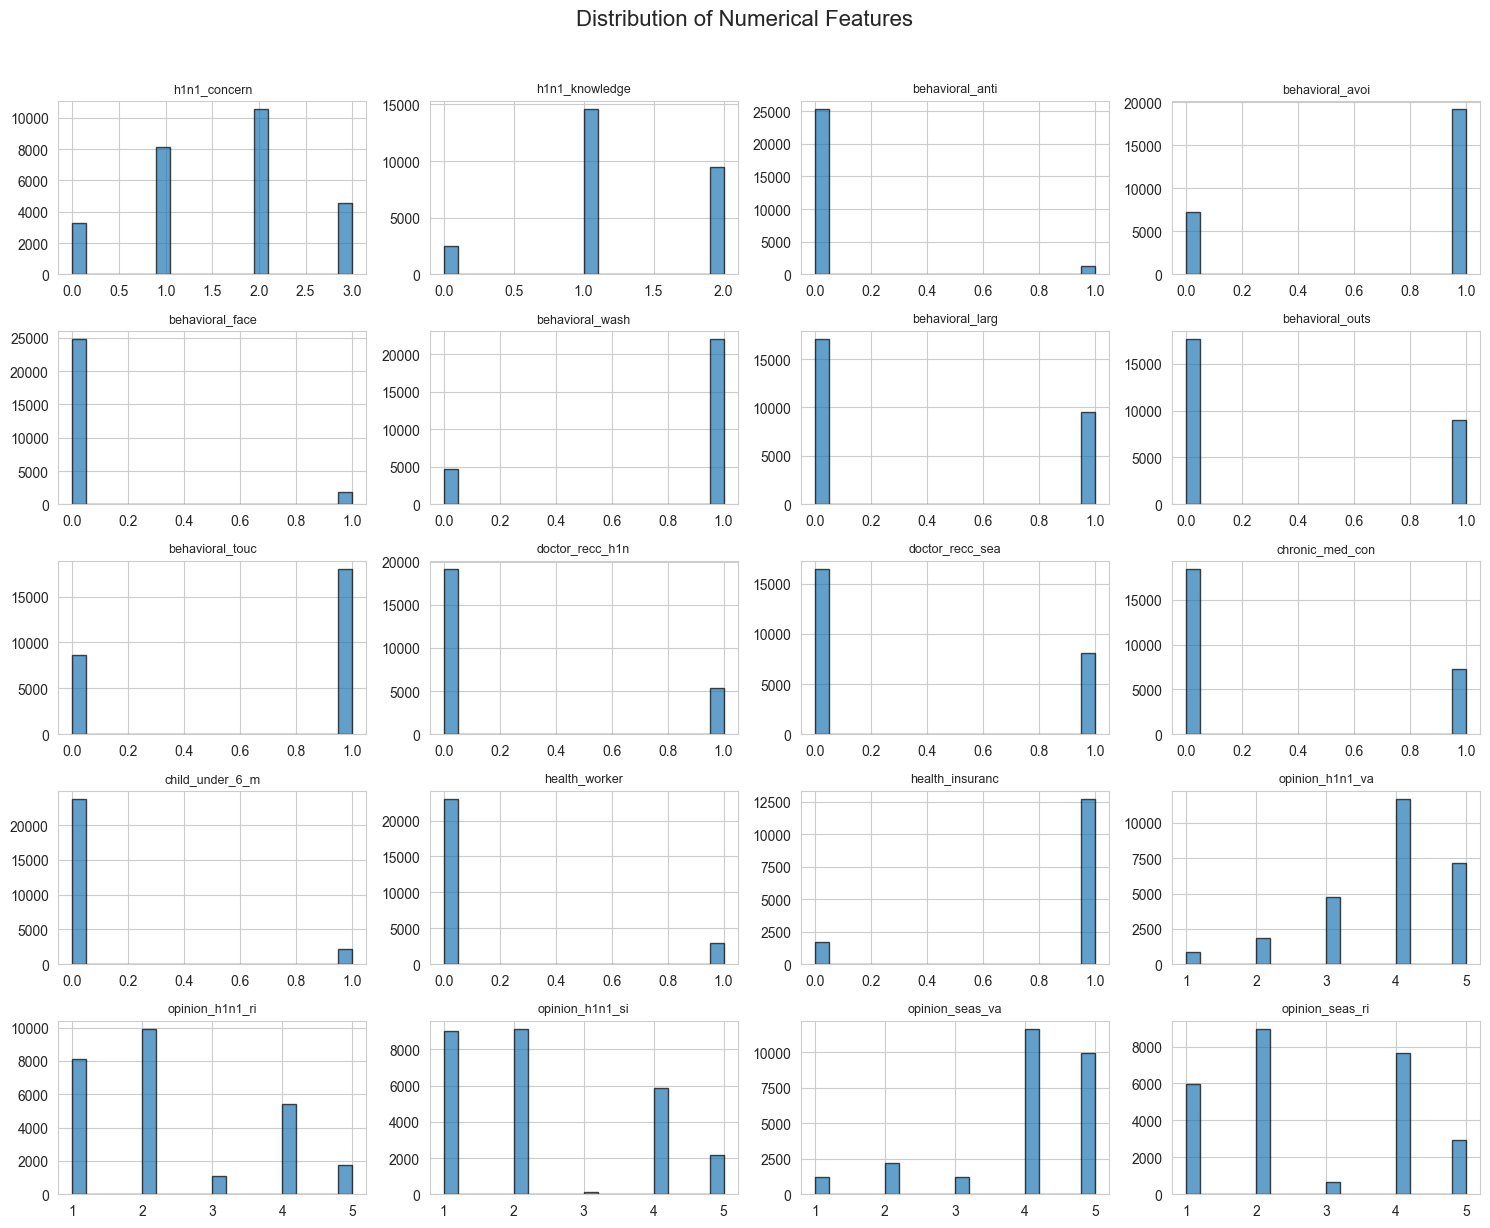

In [81]:
fig, axes = plt.subplots(5, 4, figsize=(15, 12))
axes = axes.ravel()

for i, col in enumerate(numerical_cols[:20]):
    features_df[col].hist(ax=axes[i], bins=20, edgecolor='black', alpha=0.7)
    axes[i].set_title(col[:15], fontsize=9)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

for i in range(len(numerical_cols[:20]), len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Distribution of Numerical Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

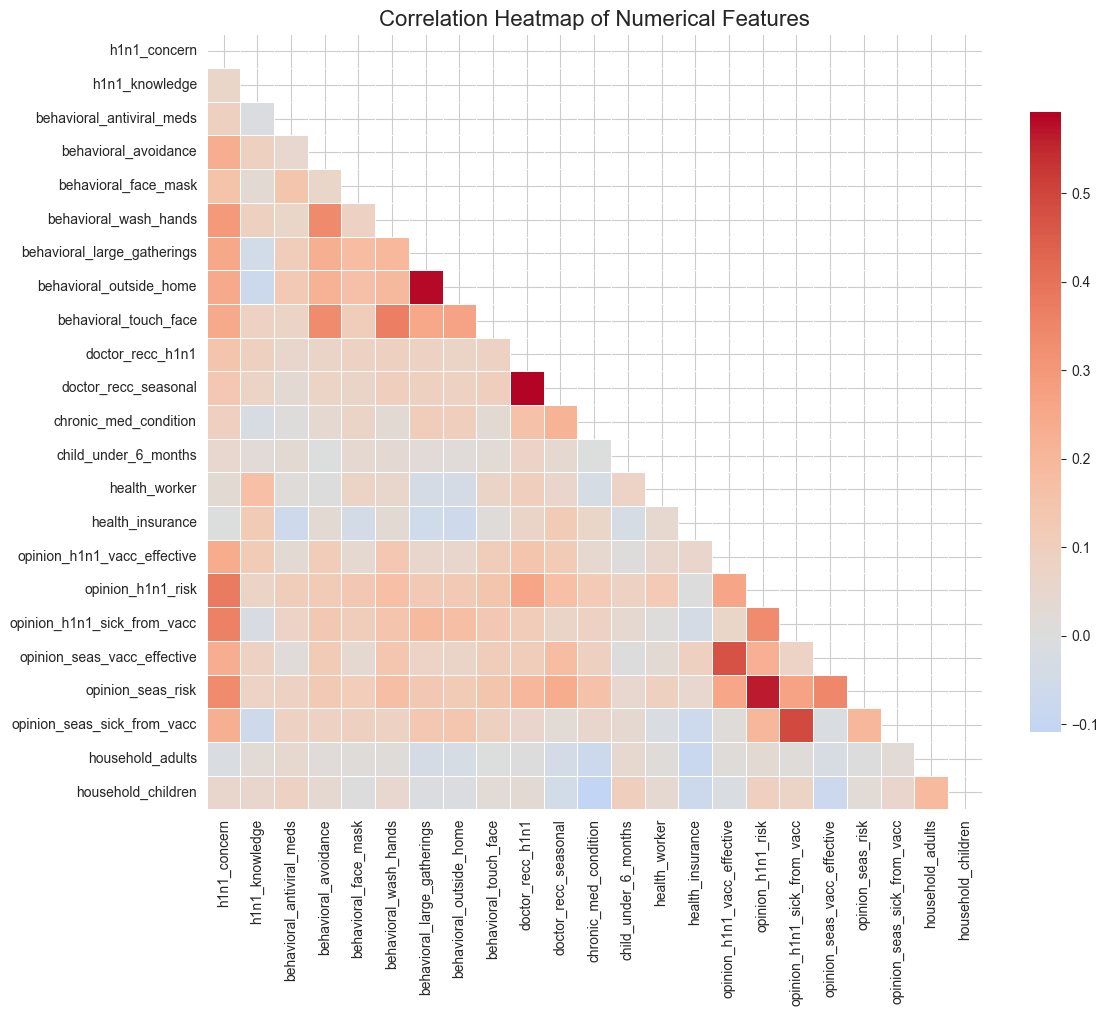


Top 10 highest absolute correlations:


doctor_recc_h1n1             doctor_recc_seasonal           0.591868
doctor_recc_seasonal         doctor_recc_h1n1               0.591868
behavioral_outside_home      behavioral_large_gatherings    0.584085
behavioral_large_gatherings  behavioral_outside_home        0.584085
opinion_seas_risk            opinion_h1n1_risk              0.564208
opinion_h1n1_risk            opinion_seas_risk              0.564208
opinion_seas_sick_from_vacc  opinion_h1n1_sick_from_vacc    0.491546
opinion_h1n1_sick_from_vacc  opinion_seas_sick_from_vacc    0.491546
opinion_h1n1_vacc_effective  opinion_seas_vacc_effective    0.472467
opinion_seas_vacc_effective  opinion_h1n1_vacc_effective    0.472467
dtype: float64

In [82]:
corr_matrix = features_df[numerical_cols].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', 
            center=0, square=True, linewidths=.5, 
            cbar_kws={"shrink": .8})
plt.title('Correlation Heatmap of Numerical Features', fontsize=16)
plt.tight_layout()
plt.show()

print("\nTop 10 highest absolute correlations:")
corr_pairs = corr_matrix.unstack().sort_values(key=abs, ascending=False)
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]
corr_pairs = corr_pairs[~corr_pairs.index.duplicated()]
display(corr_pairs.head(10))


Top 15 features correlated with vaccines:


,h1n1_vaccine,seasonal_vaccine
doctor_recc_h1n1,0.393890,0.198607
opinion_h1n1_risk,0.323265,0.216625
opinion_h1n1_vacc_effective,0.269347,0.205072
opinion_seas_risk,0.258571,0.390106
doctor_recc_seasonal,0.209864,0.369190
opinion_seas_vacc_effective,0.179272,0.361875
health_worker,0.169768,0.127311
h1n1_concern,0.121929,0.154828
health_insurance,0.121170,0.200858
h1n1_knowledge,0.117951,0.120152


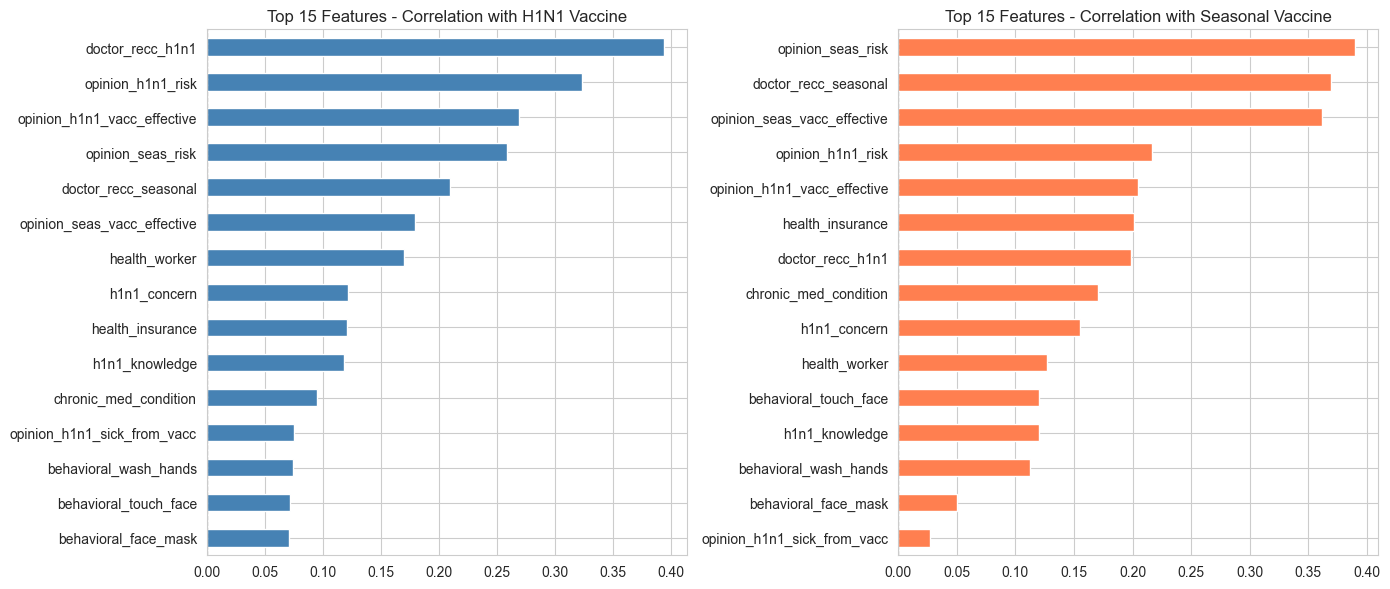

In [83]:
joined_df = features_df.join(labels_df)


target_corr = pd.DataFrame({
    'h1n1_vaccine': [joined_df[col].corr(joined_df['h1n1_vaccine']) for col in numerical_cols],
    'seasonal_vaccine': [joined_df[col].corr(joined_df['seasonal_vaccine']) for col in numerical_cols]
}, index=numerical_cols)


target_corr['abs_h1n1'] = target_corr['h1n1_vaccine'].abs()
target_corr_sorted = target_corr.sort_values('abs_h1n1', ascending=False)

print("\nTop 15 features correlated with vaccines:")
display(target_corr_sorted[['h1n1_vaccine', 'seasonal_vaccine']].head(15))


fig, axes = plt.subplots(1, 2, figsize=(14, 6))
top_features = target_corr_sorted.head(15)
top_features['h1n1_vaccine'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 15 Features - Correlation with H1N1 Vaccine')
axes[0].axvline(x=0, color='black', linestyle='--', linewidth=0.8)

top_features['seasonal_vaccine'].sort_values().plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Top 15 Features - Correlation with Seasonal Vaccine')
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

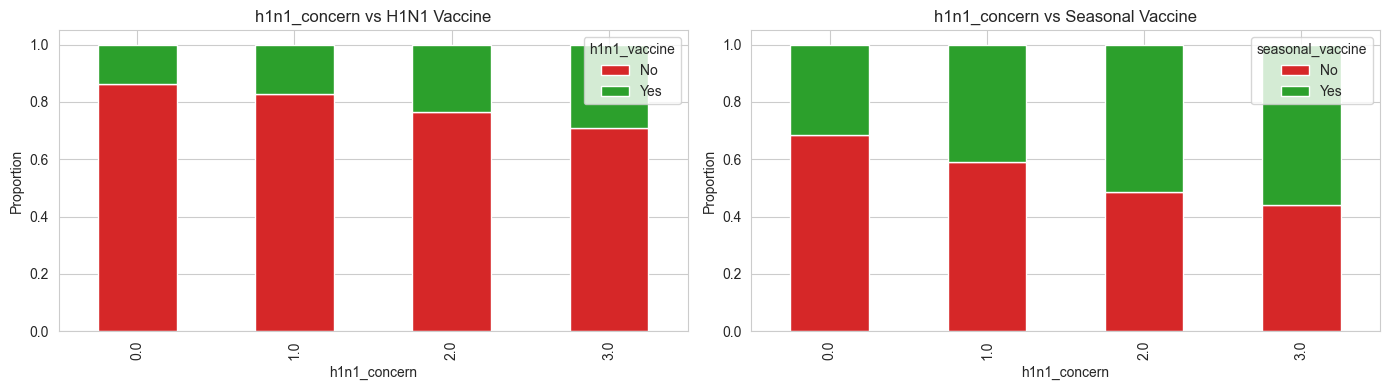

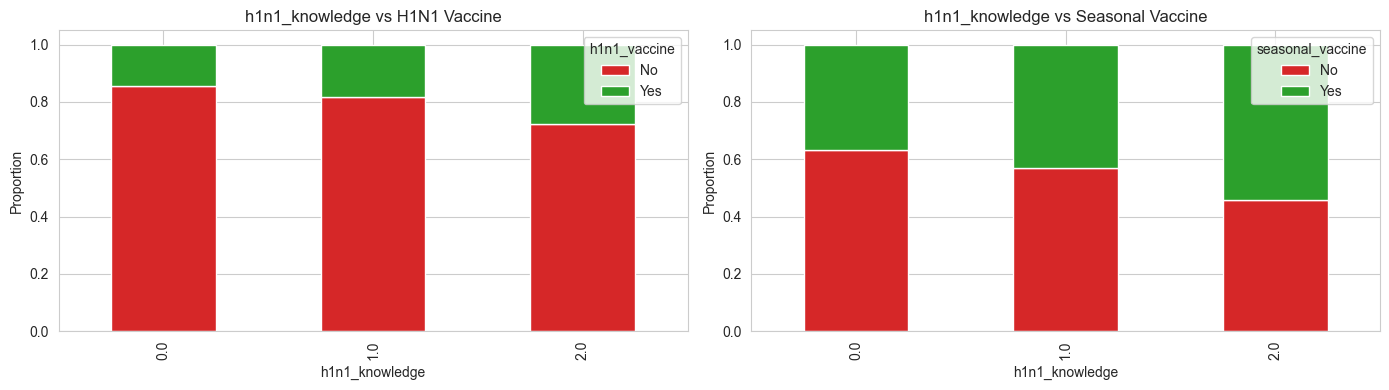

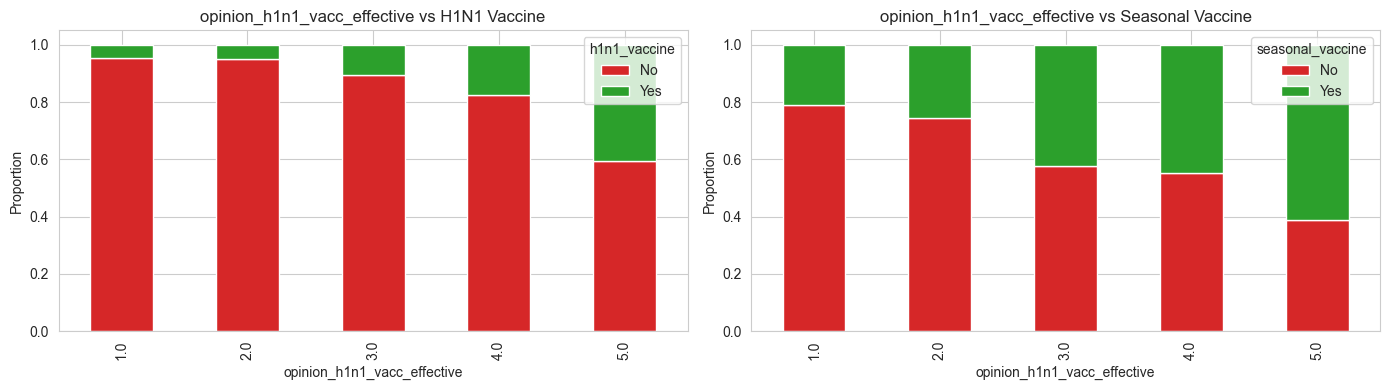

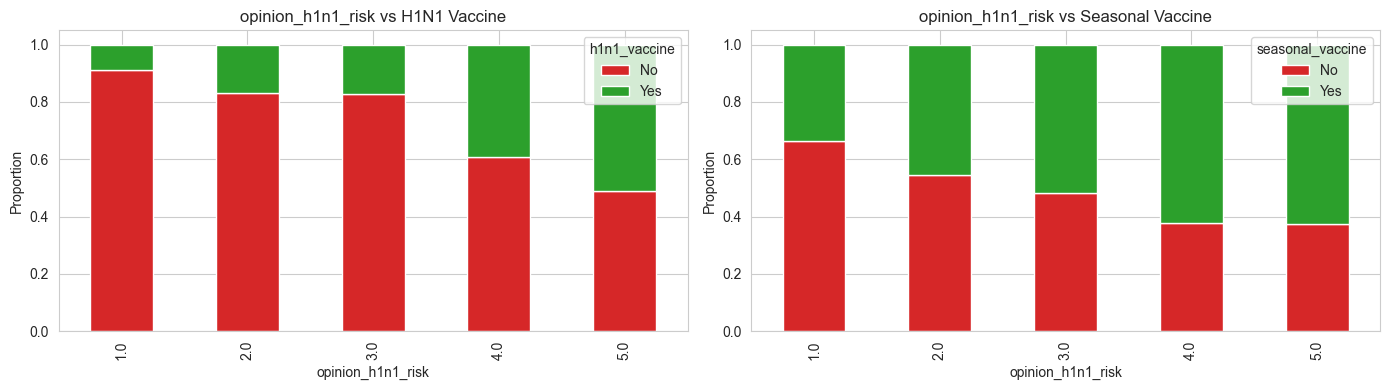

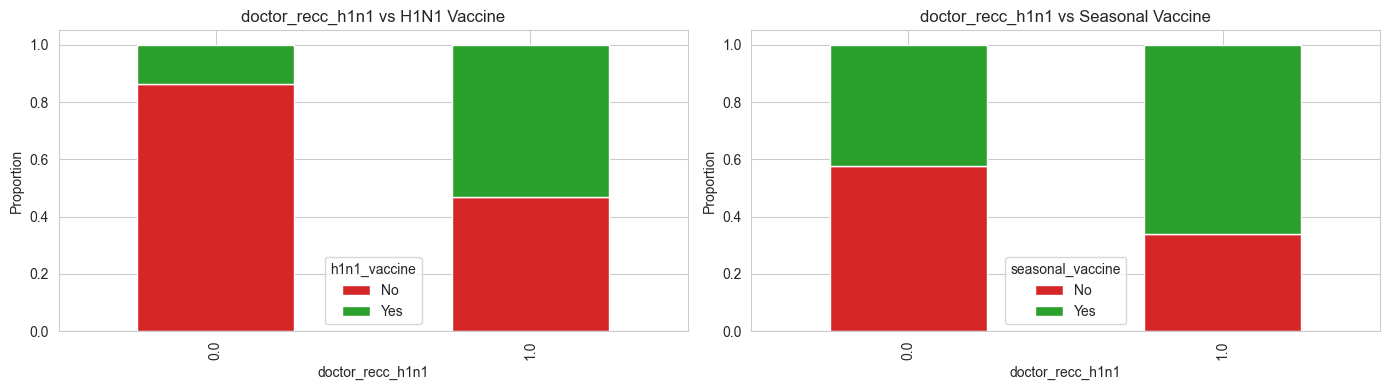

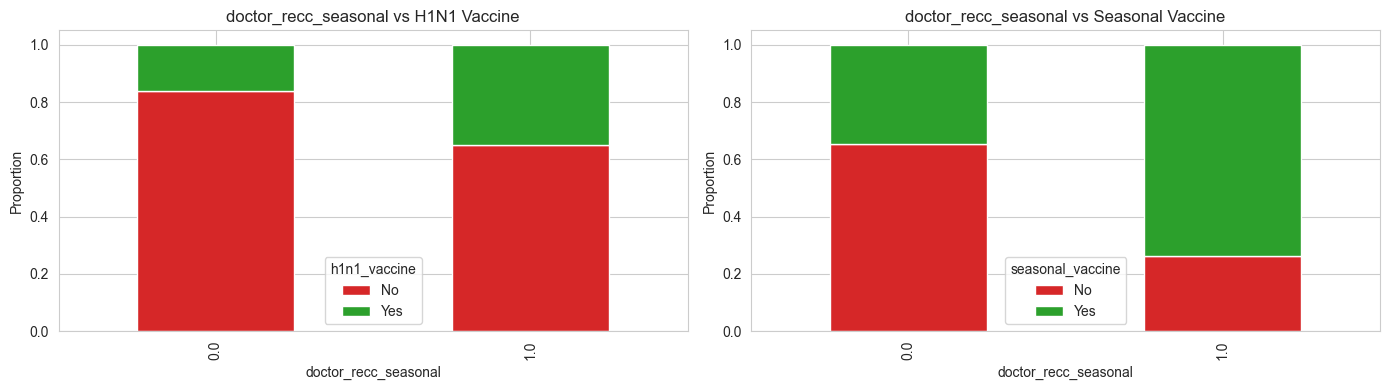

In [84]:
key_features = ['h1n1_concern', 'h1n1_knowledge', 'opinion_h1n1_vacc_effective', 
                'opinion_h1n1_risk', 'doctor_recc_h1n1', 'doctor_recc_seasonal']

for feature in key_features:
    if feature in joined_df.columns:
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        
        # H1N1 vaccine
        crosstab_h1n1 = pd.crosstab(joined_df[feature], joined_df['h1n1_vaccine'], normalize='index')
        crosstab_h1n1.plot(kind='bar', stacked=True, ax=axes[0], color=['#d62728', '#2ca02c'])
        axes[0].set_title(f'{feature} vs H1N1 Vaccine')
        axes[0].set_ylabel('Proportion')
        axes[0].legend(title='h1n1_vaccine', labels=['No', 'Yes'])
        
        # Seasonal vaccine
        crosstab_seasonal = pd.crosstab(joined_df[feature], joined_df['seasonal_vaccine'], normalize='index')
        crosstab_seasonal.plot(kind='bar', stacked=True, ax=axes[1], color=['#d62728', '#2ca02c'])
        axes[1].set_title(f'{feature} vs Seasonal Vaccine')
        axes[1].set_ylabel('Proportion')
        axes[1].legend(title='seasonal_vaccine', labels=['No', 'Yes'])
        
        plt.tight_layout()
        plt.show()

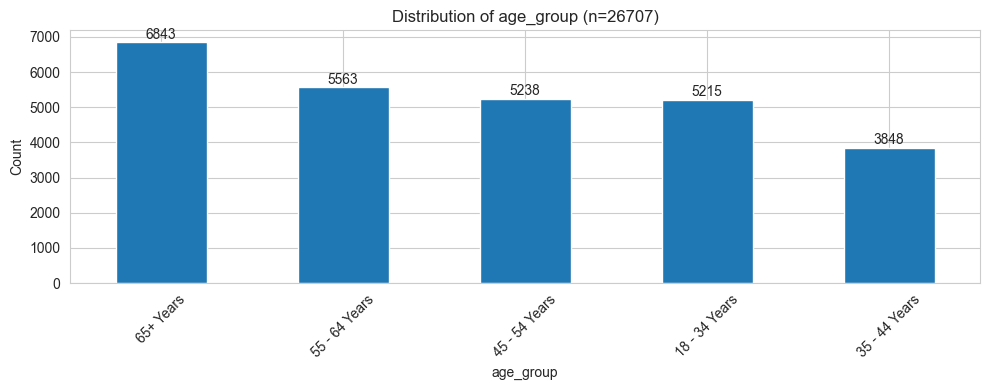

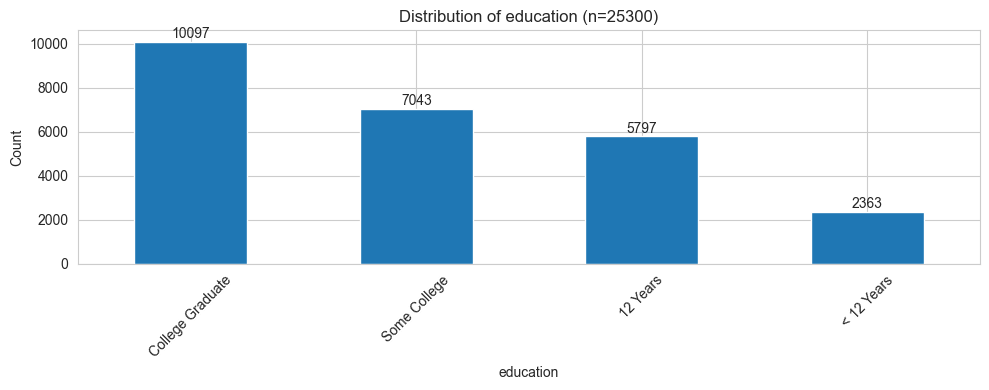

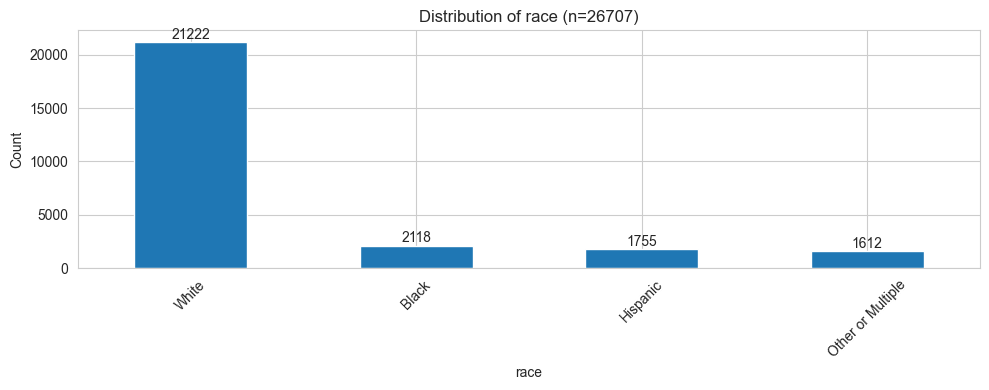

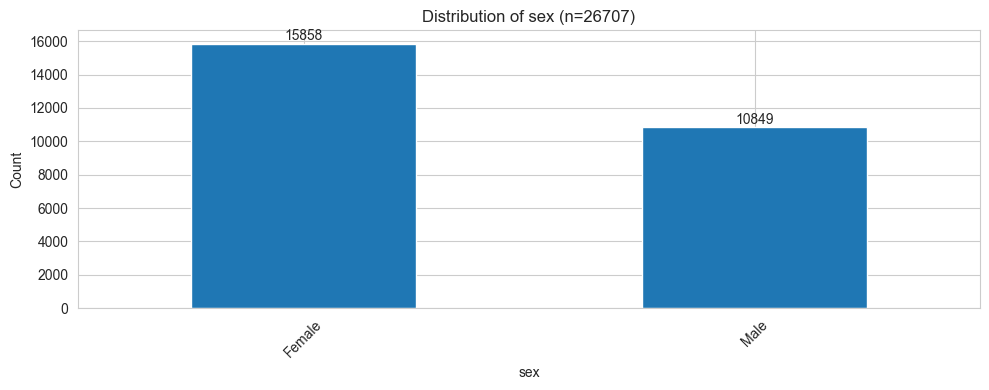

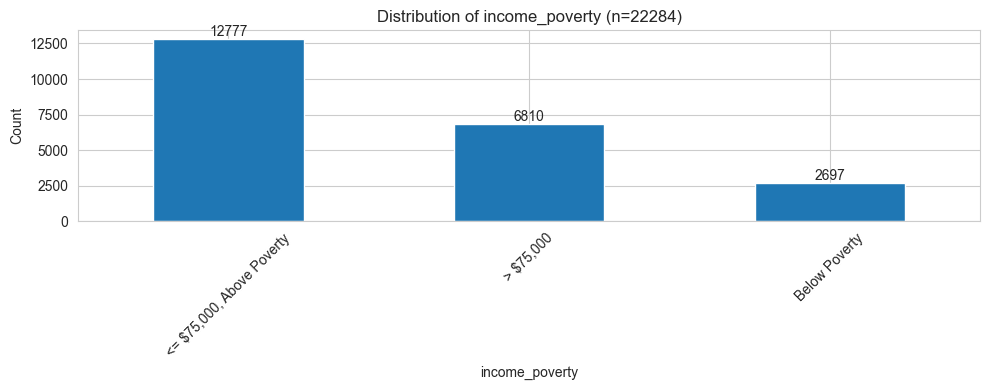

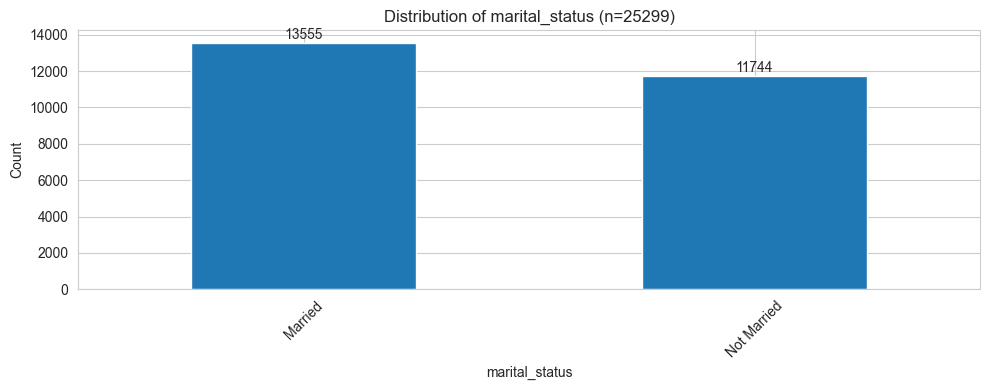

In [85]:
for i, col in enumerate(categorical_cols[:6]):
    plt.figure(figsize=(10, 4))
    value_counts = features_df[col].value_counts()
    
    bars = value_counts.plot(kind='bar')
    plt.title(f'Distribution of {col} (n={len(features_df[col].dropna())})')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    
    for idx, v in enumerate(value_counts):
        plt.text(idx, v + 20, str(v), ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()

## 7. Feature-Target Relationships

In [86]:
joined_df = features_df.join(labels_df)
print(f"Joined DataFrame Shape: {joined_df.shape}")

Joined DataFrame Shape: (26707, 37)


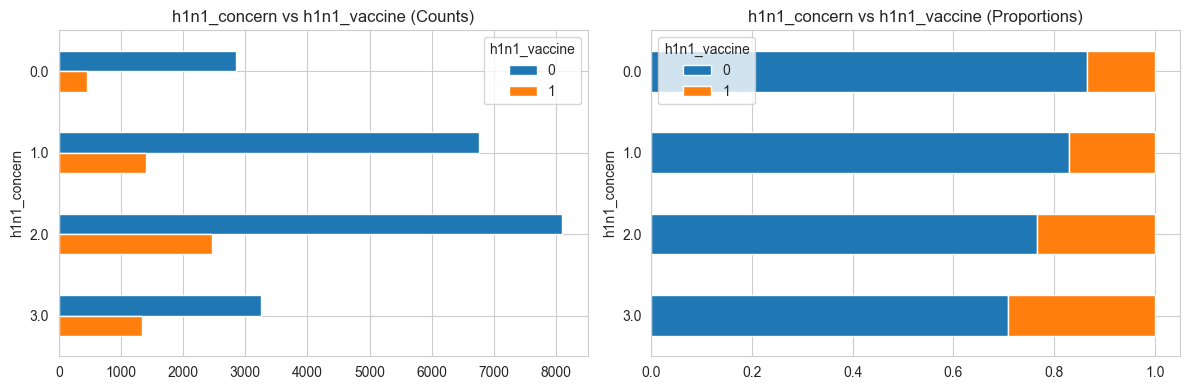

In [87]:
counts = (
    joined_df[["h1n1_concern", "h1n1_vaccine"]]
    .groupby(["h1n1_concern", "h1n1_vaccine"])
    .size()
    .unstack("h1n1_vaccine")
    .fillna(0)
)

h1n1_concern_counts = counts.sum(axis="columns")
props = counts.div(h1n1_concern_counts, axis="index")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts.plot.barh(ax=axes[0])
axes[0].invert_yaxis()
axes[0].set_title('h1n1_concern vs h1n1_vaccine (Counts)')
axes[0].legend(title='h1n1_vaccine')

props.plot.barh(stacked=True, ax=axes[1])
axes[1].invert_yaxis()
axes[1].set_title('h1n1_concern vs h1n1_vaccine (Proportions)')
axes[1].legend(title='h1n1_vaccine')

plt.tight_layout()
plt.show()

## 8. Data Quality Checks

In [88]:
print(f"Duplicate rows in features: {features_df.duplicated().sum()}")
print(f"Duplicate rows in labels: {labels_df.duplicated().sum()}")


constant_cols = [col for col in features_df.columns if features_df[col].nunique() == 1]
print(f"\nConstant columns (nunique=1): {constant_cols}")


low_variance_threshold = 0.01 
low_variance_cols = []
for col in features_df.columns:
    if features_df[col].nunique() / len(features_df) < low_variance_threshold:
        low_variance_cols.append((col, features_df[col].nunique()))

print(f"\nLow variance columns (<{low_variance_threshold*100:.0f}% unique values):")
for col, nunique in low_variance_cols[:10]:
    print(f"  {col}: {nunique} unique values")

Duplicate rows in features: 0
Duplicate rows in labels: 26703

Constant columns (nunique=1): []

Low variance columns (<1% unique values):
  h1n1_concern: 4 unique values
  h1n1_knowledge: 3 unique values
  behavioral_antiviral_meds: 2 unique values
  behavioral_avoidance: 2 unique values
  behavioral_face_mask: 2 unique values
  behavioral_wash_hands: 2 unique values
  behavioral_large_gatherings: 2 unique values
  behavioral_outside_home: 2 unique values
  behavioral_touch_face: 2 unique values
  doctor_recc_h1n1: 2 unique values


## 9. Data Preparation for Modeling

In [89]:
numeric_cols = features_df.columns[features_df.dtypes != "object"].values.tolist()
print(f"Numeric columns for modeling ({len(numeric_cols)}):")
print(numeric_cols)

Numeric columns for modeling (23):
['h1n1_concern', 'h1n1_knowledge', 'behavioral_antiviral_meds', 'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands', 'behavioral_large_gatherings', 'behavioral_outside_home', 'behavioral_touch_face', 'doctor_recc_h1n1', 'doctor_recc_seasonal', 'chronic_med_condition', 'child_under_6_months', 'health_worker', 'health_insurance', 'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk', 'opinion_h1n1_sick_from_vacc', 'opinion_seas_vacc_effective', 'opinion_seas_risk', 'opinion_seas_sick_from_vacc', 'household_adults', 'household_children']


## 10. Build Preprocessing Pipeline

In [90]:
numeric_preprocessing_steps = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

# Create column transformer
preprocessor = ColumnTransformer(
    transformers=[("numeric", numeric_preprocessing_steps, numeric_cols)],
    remainder="drop",
)

print("✓ Preprocessing pipeline created")

✓ Preprocessing pipeline created


## 11. Build Full Pipeline with Models

In [91]:
estimators = MultiOutputClassifier(
    estimator=LogisticRegression(penalty="l2", C=1, max_iter=1000, random_state=RANDOM_SEED)
)


full_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("estimators", estimators),
    ]
)

print("✓ Full pipeline created")
print(full_pipeline)

✓ Full pipeline created
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['h1n1_concern',
                                                   'h1n1_knowledge',
                                                   'behavioral_antiviral_meds',
                                                   'behavioral_avoidance',
                                                   'behavioral_face_mask',
                                                   'behavioral_wash_hands',
                                                   'behavioral_large_gatherings',
             

## 12. Train-Test Split and Model Training

In [92]:
X_train, X_eval, y_train, y_eval = train_test_split(
    features_df,
    labels_df,
    test_size=0.33,
    shuffle=True,
    stratify=labels_df,
    random_state=RANDOM_SEED,
)

print(f"Training set size: {X_train.shape[0]} ({X_train.shape[0]/len(features_df)*100:.1f}%)")
print(f"Evaluation set size: {X_eval.shape[0]} ({X_eval.shape[0]/len(features_df)*100:.1f}%)")

print("\n=== TARGET DISTRIBUTION IN SPLITS ===")
print("\nTraining set:")
print(f"  H1N1 vaccine - Yes: {y_train['h1n1_vaccine'].sum()} ({y_train['h1n1_vaccine'].mean()*100:.1f}%)")
print(f"  Seasonal vaccine - Yes: {y_train['seasonal_vaccine'].sum()} ({y_train['seasonal_vaccine'].mean()*100:.1f}%)")

print("\nEvaluation set:")
print(f"  H1N1 vaccine - Yes: {y_eval['h1n1_vaccine'].sum()} ({y_eval['h1n1_vaccine'].mean()*100:.1f}%)")
print(f"  Seasonal vaccine - Yes: {y_eval['seasonal_vaccine'].sum()} ({y_eval['seasonal_vaccine'].mean()*100:.1f}%)")

Training set size: 17893 (67.0%)
Evaluation set size: 8814 (33.0%)

=== TARGET DISTRIBUTION IN SPLITS ===

Training set:
  H1N1 vaccine - Yes: 3802 (21.2%)
  Seasonal vaccine - Yes: 8331 (46.6%)

Evaluation set:
  H1N1 vaccine - Yes: 1872 (21.2%)
  Seasonal vaccine - Yes: 4104 (46.6%)


In [93]:
%%time

full_pipeline.fit(X_train, y_train)
print("\n✓ Model training complete")


✓ Model training complete
CPU times: total: 281 ms
Wall time: 296 ms


C:\Users\user\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\user\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


## 13. Model Evaluation

In [94]:
preds = full_pipeline.predict_proba(X_eval)

print(f"H1N1 predictions shape: {preds[0].shape}")
print(f"Seasonal predictions shape: {preds[1].shape}")

H1N1 predictions shape: (8814, 2)
Seasonal predictions shape: (8814, 2)


In [95]:
y_preds = pd.DataFrame(
    {
        "h1n1_vaccine": preds[0][:, 1],
        "seasonal_vaccine": preds[1][:, 1],
    },
    index=y_eval.index,
)

print(f"Predictions shape: {y_preds.shape}")
display(y_preds.head())

Predictions shape: (8814, 2)


,h1n1_vaccine,seasonal_vaccine
respondent_id,,
6728,0.290919,0.472745
16516,0.097748,0.381666
3106,0.155387,0.630014
16981,0.661696,0.857856
19111,0.284458,0.776957


=== FEATURE IMPORTANCE FROM MODEL ===

Top 10 Most Important Features for H1N1:


,feature,h1n1_coefficient
9,doctor_recc_h1n1,0.781899
15,opinion_h1n1_vacc_effective,0.617338
16,opinion_h1n1_risk,0.448924
13,health_worker,0.235792
19,opinion_seas_risk,0.204312
10,doctor_recc_seasonal,-0.185159
20,opinion_seas_sick_from_vacc,-0.134469
22,household_children,-0.119463
1,h1n1_knowledge,0.118603
6,behavioral_large_gatherings,-0.112843



Top 10 Most Important Features for Seasonal:


,feature,seasonal_coefficient
10,doctor_recc_seasonal,0.710221
19,opinion_seas_risk,0.707121
18,opinion_seas_vacc_effective,0.637771
20,opinion_seas_sick_from_vacc,-0.291113
22,household_children,-0.248377
13,health_worker,0.237736
14,health_insurance,0.223966
11,chronic_med_condition,0.148363
9,doctor_recc_h1n1,-0.144209
1,h1n1_knowledge,0.113332


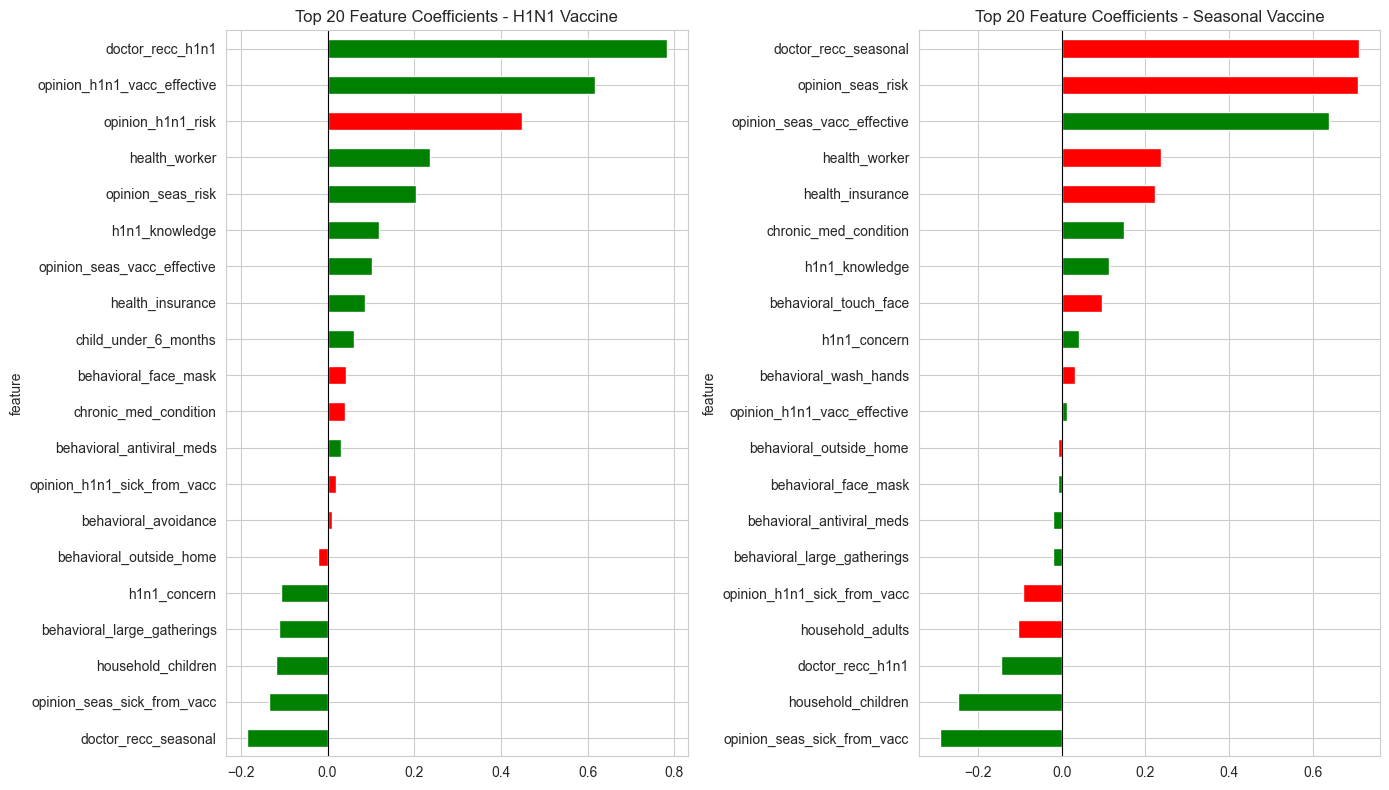

In [96]:
print("=== FEATURE IMPORTANCE FROM MODEL ===")

h1n1_model = full_pipeline.named_steps['estimators'].estimators_[0]
seasonal_model = full_pipeline.named_steps['estimators'].estimators_[1]

feature_importance = pd.DataFrame({
    'feature': numeric_cols,
    'h1n1_coefficient': h1n1_model.coef_[0],
    'seasonal_coefficient': seasonal_model.coef_[0],
    'h1n1_abs': np.abs(h1n1_model.coef_[0]),
    'seasonal_abs': np.abs(seasonal_model.coef_[0])
})

feature_importance_h1n1 = feature_importance.sort_values('h1n1_abs', ascending=False)
feature_importance_seasonal = feature_importance.sort_values('seasonal_abs', ascending=False)

print("\nTop 10 Most Important Features for H1N1:")
display(feature_importance_h1n1[['feature', 'h1n1_coefficient']].head(10))

print("\nTop 10 Most Important Features for Seasonal:")
display(feature_importance_seasonal[['feature', 'seasonal_coefficient']].head(10))

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

top_h1n1 = feature_importance_h1n1.head(20)
colors_h1n1 = ['green' if x > 0 else 'red' for x in top_h1n1['h1n1_coefficient']]
top_h1n1.set_index('feature')['h1n1_coefficient'].sort_values().plot(
    kind='barh', ax=axes[0], color=colors_h1n1
)
axes[0].set_title('Top 20 Feature Coefficients - H1N1 Vaccine')
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=0.8)

top_seasonal = feature_importance_seasonal.head(20)
colors_seasonal = ['green' if x > 0 else 'red' for x in top_seasonal['seasonal_coefficient']]
top_seasonal.set_index('feature')['seasonal_coefficient'].sort_values().plot(
    kind='barh', ax=axes[1], color=colors_seasonal
)
axes[1].set_title('Top 20 Feature Coefficients - Seasonal Vaccine')
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=0.8)

plt.tight_layout()
plt.show()

In [97]:
def plot_roc(y_true, y_score, label_name, ax):
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    auc_score = roc_auc_score(y_true, y_score)
    ax.plot(fpr, tpr, label=f'AUC = {auc_score:.4f}')
    ax.plot([0, 1], [0, 1], color="grey", linestyle="--", label='Random')
    ax.set_ylabel("TPR")
    ax.set_xlabel("FPR")
    ax.set_title(f"{label_name}")
    ax.legend()
    return auc_score

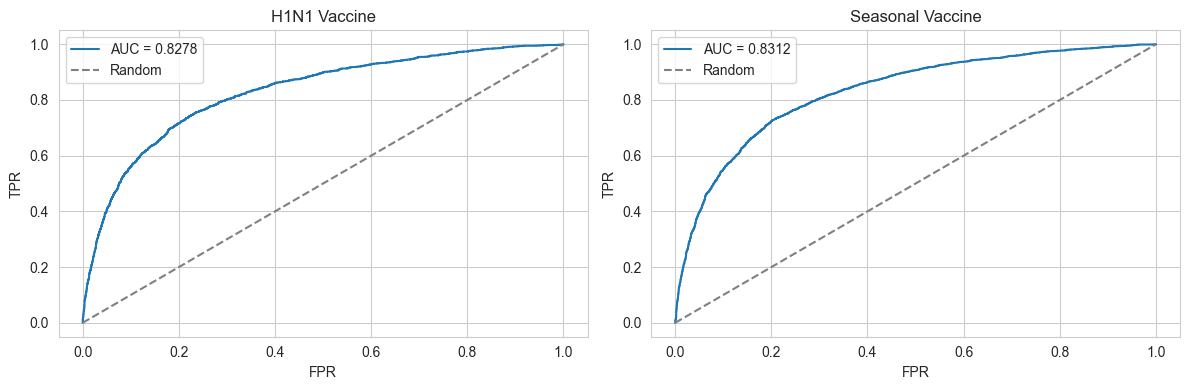


Evaluation Set Performance:
  H1N1 AUC: 0.8278
  Seasonal AUC: 0.8312


In [98]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

h1n1_auc = plot_roc(y_eval["h1n1_vaccine"], y_preds["h1n1_vaccine"], "H1N1 Vaccine", ax=ax[0])
seasonal_auc = plot_roc(y_eval["seasonal_vaccine"], y_preds["seasonal_vaccine"], "Seasonal Vaccine", ax=ax[1])

plt.tight_layout()
plt.show()

print(f"\nEvaluation Set Performance:")
print(f"  H1N1 AUC: {h1n1_auc:.4f}")
print(f"  Seasonal AUC: {seasonal_auc:.4f}")

In [99]:
overall_auc = roc_auc_score(y_eval, y_preds)
print(f"\nOverall AUC Score: {overall_auc:.4f}")


Overall AUC Score: 0.8295


## 14. Train on Full Data and Generate Predictions

In [100]:
%%time

full_pipeline.fit(features_df, labels_df)
print("\n✓ Model retraining on full dataset complete")


✓ Model retraining on full dataset complete
CPU times: total: 328 ms
Wall time: 265 ms


C:\Users\user\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\user\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [101]:
test_features_df = pd.read_csv(
    DATA_PATH / "test_set_features.csv", index_col="respondent_id"
)

submission_df = pd.read_csv(
    DATA_PATH / "submission_format.csv", index_col="respondent_id"
)

print(f"Test features shape: {test_features_df.shape}")
print(f"Submission template shape: {submission_df.shape}")

Test features shape: (26708, 35)
Submission template shape: (26708, 2)


In [102]:
np.testing.assert_array_equal(test_features_df.index.values, submission_df.index.values)
print("✓ Test indices match submission template")

✓ Test indices match submission template


In [103]:
test_probas = full_pipeline.predict_proba(test_features_df)

print(f"Test H1N1 predictions shape: {test_probas[0].shape}")
print(f"Test Seasonal predictions shape: {test_probas[1].shape}")

Test H1N1 predictions shape: (26708, 2)
Test Seasonal predictions shape: (26708, 2)


In [104]:
submission_df["h1n1_vaccine"] = test_probas[0][:, 1]
submission_df["seasonal_vaccine"] = test_probas[1][:, 1]

print("Submission file preview:")
display(submission_df.head())
print(f"\nSubmission file shape: {submission_df.shape}")

Submission file preview:


,h1n1_vaccine,seasonal_vaccine
respondent_id,,
26707,0.127210,0.426262
26708,0.055245,0.071200
26709,0.370987,0.637465
26710,0.464168,0.803559
26711,0.286598,0.634874



Submission file shape: (26708, 2)


In [105]:
submission_df.to_csv("my_submission.csv", index=True)
print("✓ Submission file saved as 'my_submission.csv'")

✓ Submission file saved as 'my_submission.csv'


In [106]:
!head -5 my_submission.csv

'head' is not recognized as an internal or external command,
operable program or batch file.


## 15. Summary Report

In [107]:
print(f"\n1. DATASET OVERVIEW")
print(f"   - Training samples: {len(features_df):,}")
print(f"   - Test samples: {len(test_features_df):,}")
print(f"   - Features: {features_df.shape[1]} ({len(numerical_cols)} numerical, {len(categorical_cols)} categorical)")
print(f"   - Memory: {features_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print(f"\n2. TARGET DISTRIBUTION")
h1n1_pos = labels_df['h1n1_vaccine'].sum()
seasonal_pos = labels_df['seasonal_vaccine'].sum()
print(f"   - H1N1: {h1n1_pos:,} positive ({h1n1_pos/len(labels_df)*100:.1f}%)")
print(f"   - Seasonal: {seasonal_pos:,} positive ({seasonal_pos/len(labels_df)*100:.1f}%)")
print(f"   - Correlation: {correlation:.4f}")

print(f"\n3. DATA QUALITY")
total_missing = features_df.isnull().sum().sum()
print(f"   - Missing values: {total_missing:,} ({total_missing/(features_df.shape[0]*features_df.shape[1])*100:.2f}%)")
print(f"   - Duplicates: {features_df.duplicated().sum()}")
print(f"   - Imputation: Median strategy applied via pipeline")

print(f"\n4. MODEL PERFORMANCE")
print(f"   - H1N1 Vaccine AUC: {h1n1_auc:.4f}")
print(f"   - Seasonal Vaccine AUC: {seasonal_auc:.4f}")
print(f"   - Overall Mean AUC: {overall_auc:.4f}")

print(f"\n5. TOP PREDICTIVE FEATURES")
print(f"   H1N1: {', '.join(feature_importance_h1n1['feature'].head(3).tolist())}")
print(f"   Seasonal: {', '.join(feature_importance_seasonal['feature'].head(3).tolist())}")

print(f"\n6. OUTPUT")
print(f"   - File: my_submission.csv")
print(f"   - Samples: {len(submission_df):,}")



1. DATASET OVERVIEW
   - Training samples: 26,707
   - Test samples: 26,708
   - Features: 35 (23 numerical, 12 categorical)
   - Memory: 21.99 MB

2. TARGET DISTRIBUTION
   - H1N1: 5,674 positive (21.2%)
   - Seasonal: 12,435 positive (46.6%)
   - Correlation: 0.3771

3. DATA QUALITY
   - Missing values: 60,762 (6.50%)
   - Duplicates: 0
   - Imputation: Median strategy applied via pipeline

4. MODEL PERFORMANCE
   - H1N1 Vaccine AUC: 0.8278
   - Seasonal Vaccine AUC: 0.8312
   - Overall Mean AUC: 0.8295

5. TOP PREDICTIVE FEATURES
   H1N1: doctor_recc_h1n1, opinion_h1n1_vacc_effective, opinion_h1n1_risk
   Seasonal: doctor_recc_seasonal, opinion_seas_risk, opinion_seas_vacc_effective

6. OUTPUT
   - File: my_submission.csv
   - Samples: 26,708
